In [2]:
%load_ext autoreload
%autoreload 2

# 📱 Android 一键监控与实验场
运行下方 Cell，自动完成：**驱动激活 -> UI 语义扫描 -> 实时截屏显示**。

In [3]:
import os
import sys
import time
from IPython.display import Image, display

# 路径修正
os.environ['PYTHONPATH'] = "."
sys.path.append(".")

from device_controller import ADBController
from adb_utils import _adb_ensure_keyboard

c = ADBController()

print("🚀 [Step 1] 启动全方位体检...")

# A. 驱动激活
if _adb_ensure_keyboard():
    print("✅ 驱动状态：ADBKeyboard 已就绪 (支持中文与 IME Action)")
else:
    print("⚠️ 驱动状态：未检测到 ADBKeyboard")

🚀 [Step 1] 启动全方位体检...
✅ 驱动状态：ADBKeyboard 已就绪 (支持中文与 IME Action)


📡 正在扫描 UI 层级...

📊 发现 114 个可操作控件：
[ 0] 'Search settings' id:og-te                    @ [80, 359]
[ 1] 'Main menu'                                   @ [80, 359]
[ 2] 'Back' id:tsuid_DD4Far_DM43ekPIPn7W-6AE_1     @ [78, 338]
[ 3] (EditText)                                    @ [477, 337]
[ 4] 'Search by voice' id:Q7Ulpb                   @ [877, 338]
[ 5] desc:'Search using your camera or photos'     @ [1003, 338]
[ 6] ListView                                      @ [545, 1095]
[ 7] 'nvidia股票'                                    @ [482, 465]
[ 8] 'Delete nvidia股票 from search history'         @ [1002, 465]
[ 9] 'cute cat wallpaper'                          @ [482, 591]
[10] 'Delete cute cat wallpaper from search history' @ [1002, 591]
[11] 'nvidia stock price'                          @ [482, 717]
[12] 'Delete nvidia stock price from search history' @ [1002, 717]
[13] 'deepseek-v3 性能评测'                            @ [482, 843]
[14] 'Delete deepseek-v3 性能评测 from search history' @ [1002, 843]

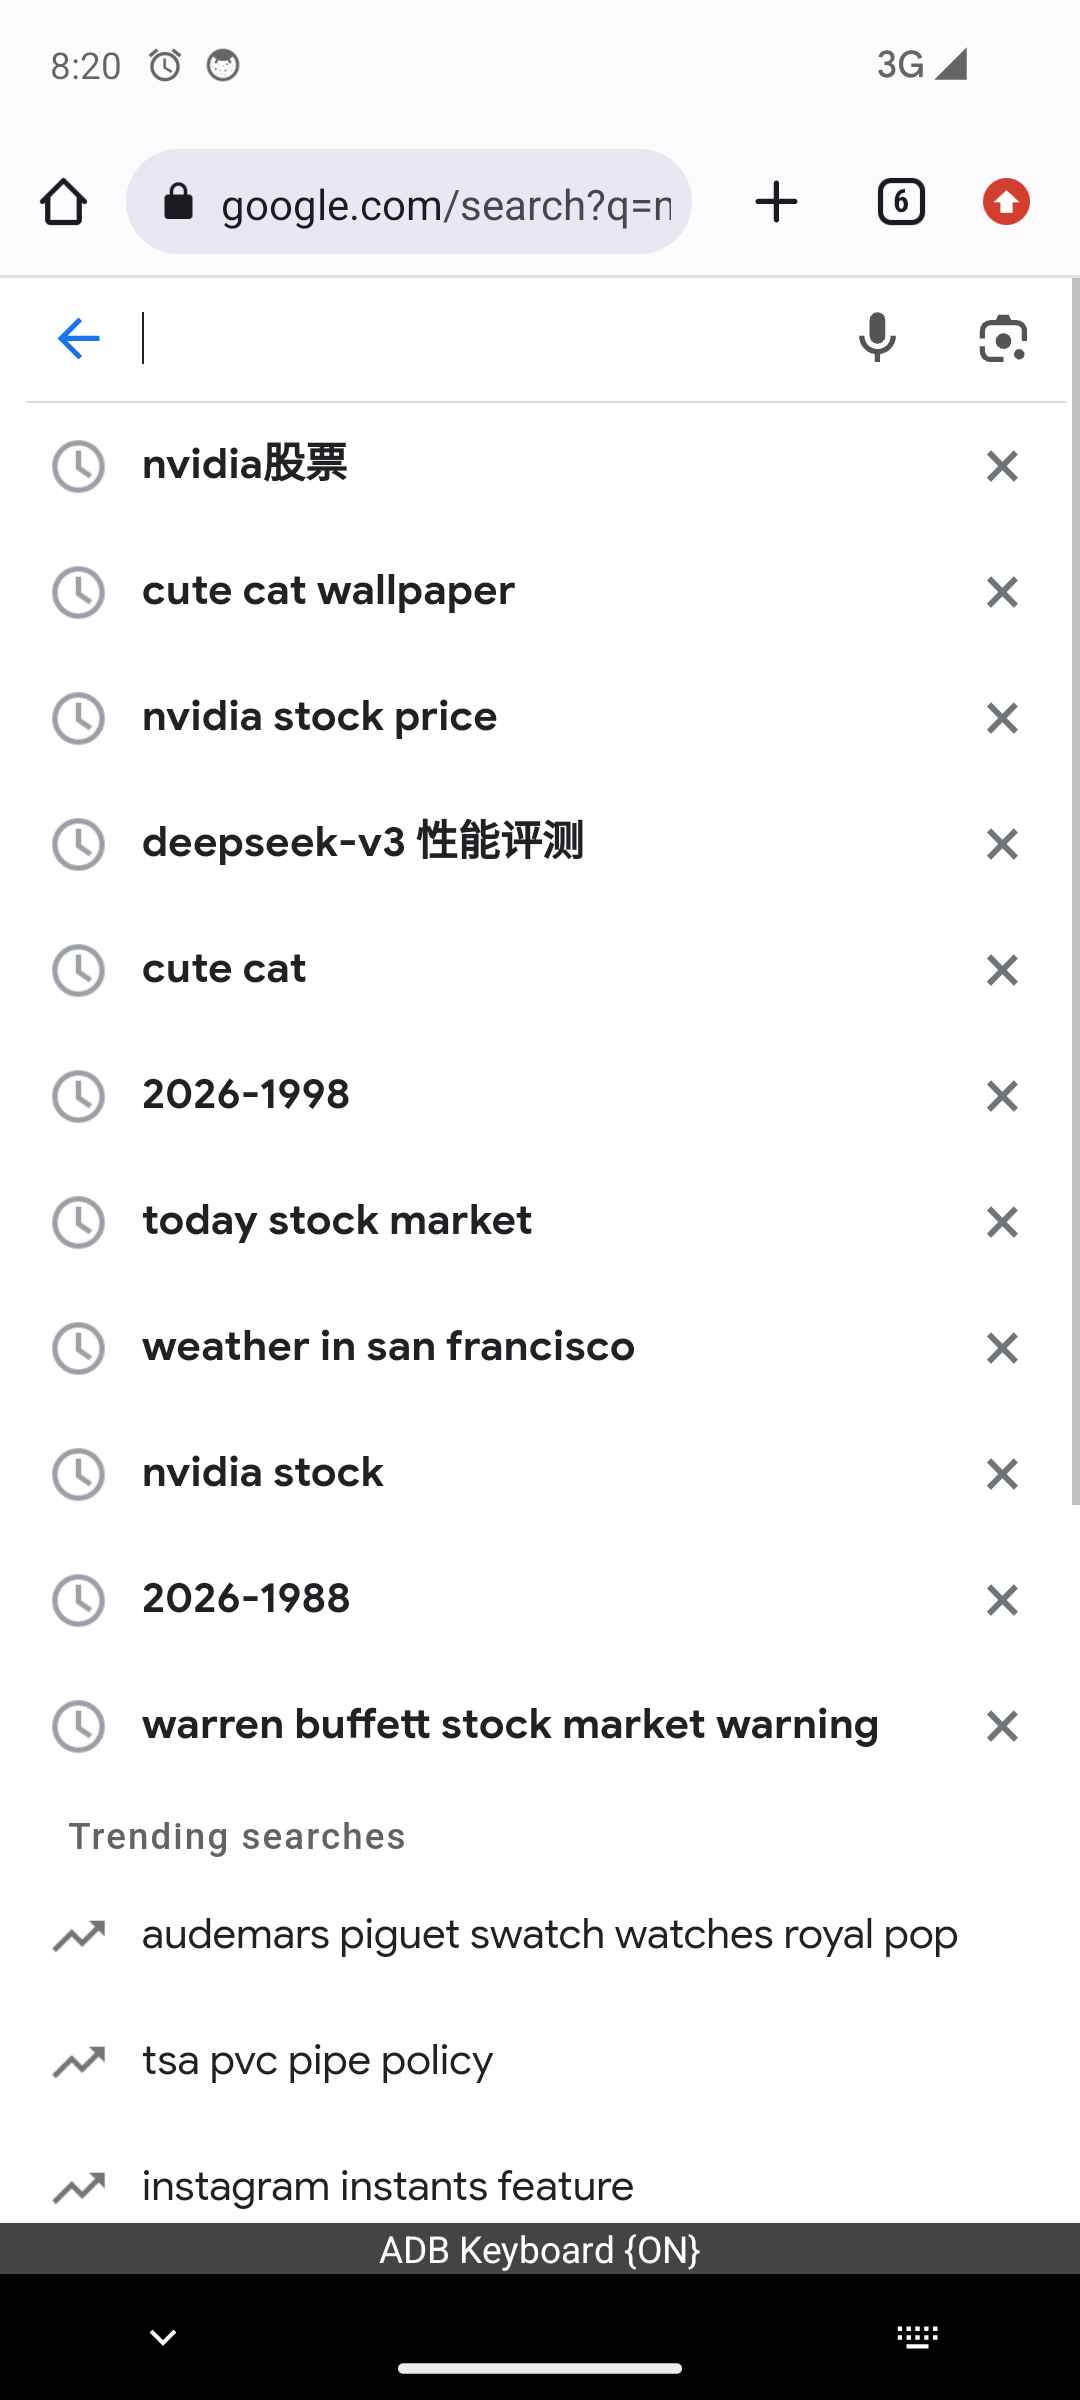

In [4]:

def visualize_screen():
    # B. UI 语义扫描 (XML Tree -> Inventory)
    print("📡 正在扫描 UI 层级...")
    inv = c.get_inventory()

    # C. 抓取并显示截屏
    screenshot_path = "profiling/last_action_result.png"
    c.take_screenshot(screenshot_path)

    # D. 结构化输出结果
    print(f"\n📊 发现 {len(inv)} 个可操作控件：")
    print("=" * 60)
    for i, e in enumerate(inv):
        if "Widget" not in e['label']:
            print(f"[{i:2d}] {e['label']:<45} @ {e['pos']}")
    print("=" * 60)

    # E. 渲染画面
    print("🖼️ 当前屏幕实况：")
    display(Image(filename=screenshot_path))

    return inv 

inv = visualize_screen()

In [5]:
def get_element_by_id(inv, target_id):
    """
    输入 ID，直接返回 (label, x, y) 三元组
    """
    if 0 <= target_id < len(inv):
        item = inv[target_id]
        return item['label'], item['pos'][0], item['pos'][1]
    return None, None, None

print(get_element_by_id(inv, 36))
print([(i, get_element_by_id(inv, i)) for i in range(35, 40)])



("'AI Mode'", 120, 618)
[(35, ("desc:'AI Mode'", 119, 618)), (36, ("'AI Mode'", 120, 618)), (37, ('View', 284, 618)), (38, ("desc:'All'", 284, 618)), (39, ("'All'", 284, 618))]


In [6]:
c.tap_and_type(553, 2137, "我想你了", editor_action="send")


[*] 📨 触发 IME editor action: send (code=4)


In [7]:
c.back()



In [8]:
# import importlib
# import device_controller
# # 强制重载文件
# importlib.reload(device_controller)

# from device_controller import ADBController
# c = ADBController()

# 1. 搜地图
# c.go_to("map", "best cafe in shanghai")

# # 2. 发短信
c.go_to("sms", "100865")

# # 3. 进设置
# c.go_to("settings")

# # 4. 进 WiFi
# c.go_to("wifi")



[*] 🌌 语义传送: sms(100865) -> android.intent.action.VIEW


In [18]:
# # 5. 甚至可以直接丢网址
# c.go_to("web", "https://github.com")

# c.go_to("route", {"origin": "上海南站", "destination": "虹桥机场"})
# c.go_to("twitter", "elonmusk")

# c.go_to("reddit_search", "adb automation tricks")
# c.go_to("twitter_search", "AI agents")
c.go_to("search", "DeepSeek-V3 性能评测")

[*] 🌌 语义传送: search(DeepSeek-V3 性能评测) -> android.intent.action.VIEW


In [48]:
c.scroll_down()

In [58]:
c.scroll_up()

In [56]:
c.back()

In [57]:
c.go_to("alarm", {"hour": 9, "minutes": 30, "message": "Gym"})

[*] 🌌 语义传送: alarm({'hour': 9, 'minutes': 30, 'message': 'Gym'}) -> android.intent.action.SET_ALARM


In [ ]:
# import importlib
# import device_controller
# # 强制重载文件
# importlib.reload(device_controller)

# from device_controller import ADBController
# c = ADBController()

# 我发现需要先 tap 啊，怎么回事啊，不然不能直接 type 呢乖乖。。
_adb_ensure_keyboard()
c.type("123", clear_first=True, editor_action="search")


TypeError: ADBController.tap_and_type() missing 2 required positional arguments: 'y' and 'text'

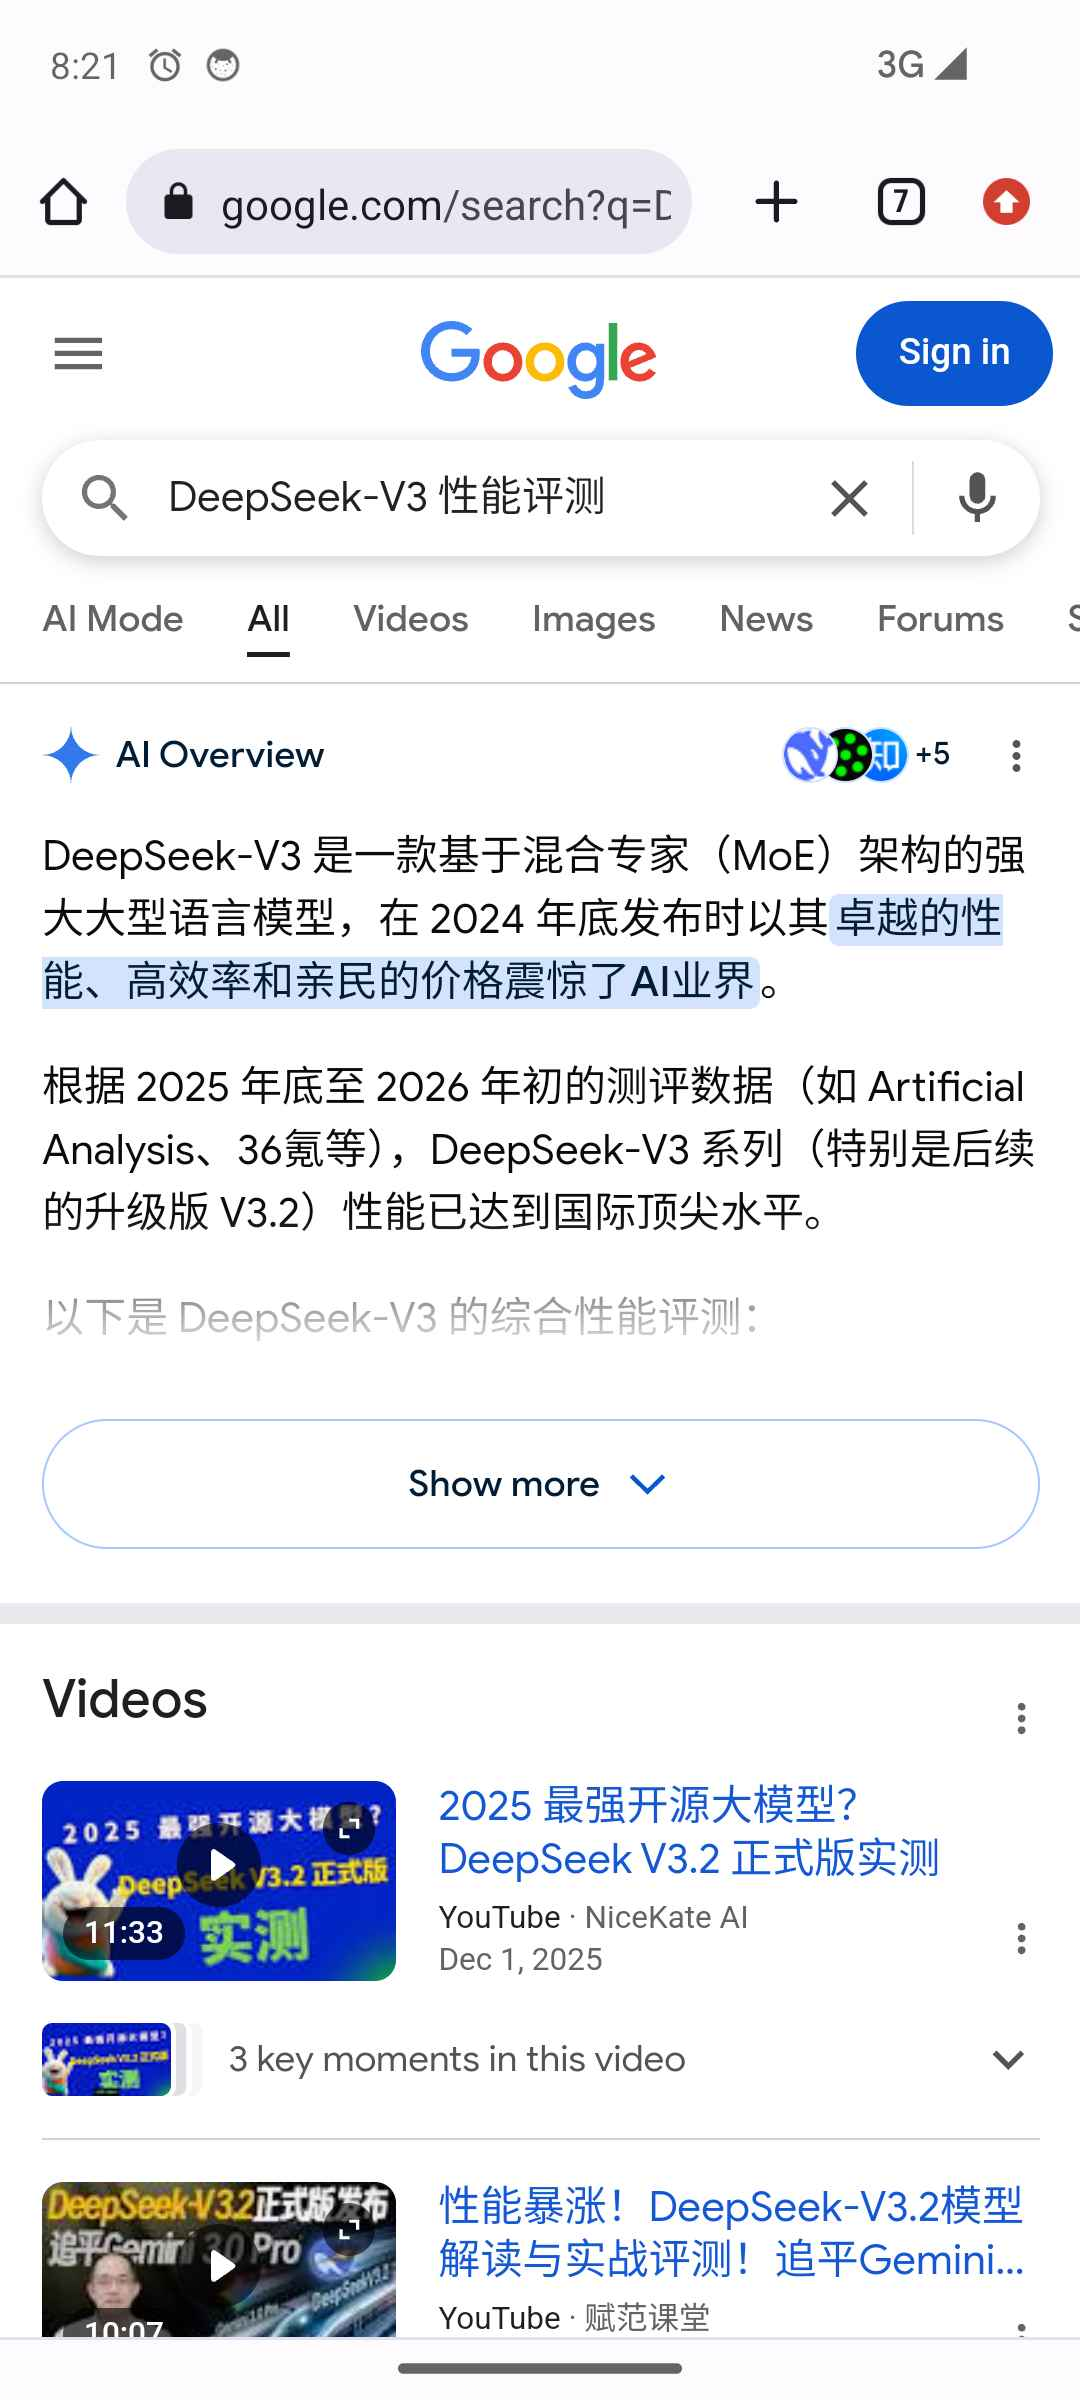

In [15]:
screenshot_path = "profiling/last_action_result.png"
c.take_screenshot(screenshot_path)
display(Image(filename=screenshot_path))

### 🎮 2. 指令执行 (Action)
请根据上方清单的 ID 修改下方的 `target_id` 进行操作。

🚀 正在执行：点击 desc:'Add files, location, and more' id:plus_button 并输入 '嗯，爱你一万年' (Action: send)
[*] 📨 触发 IME editor action: send (code=4)


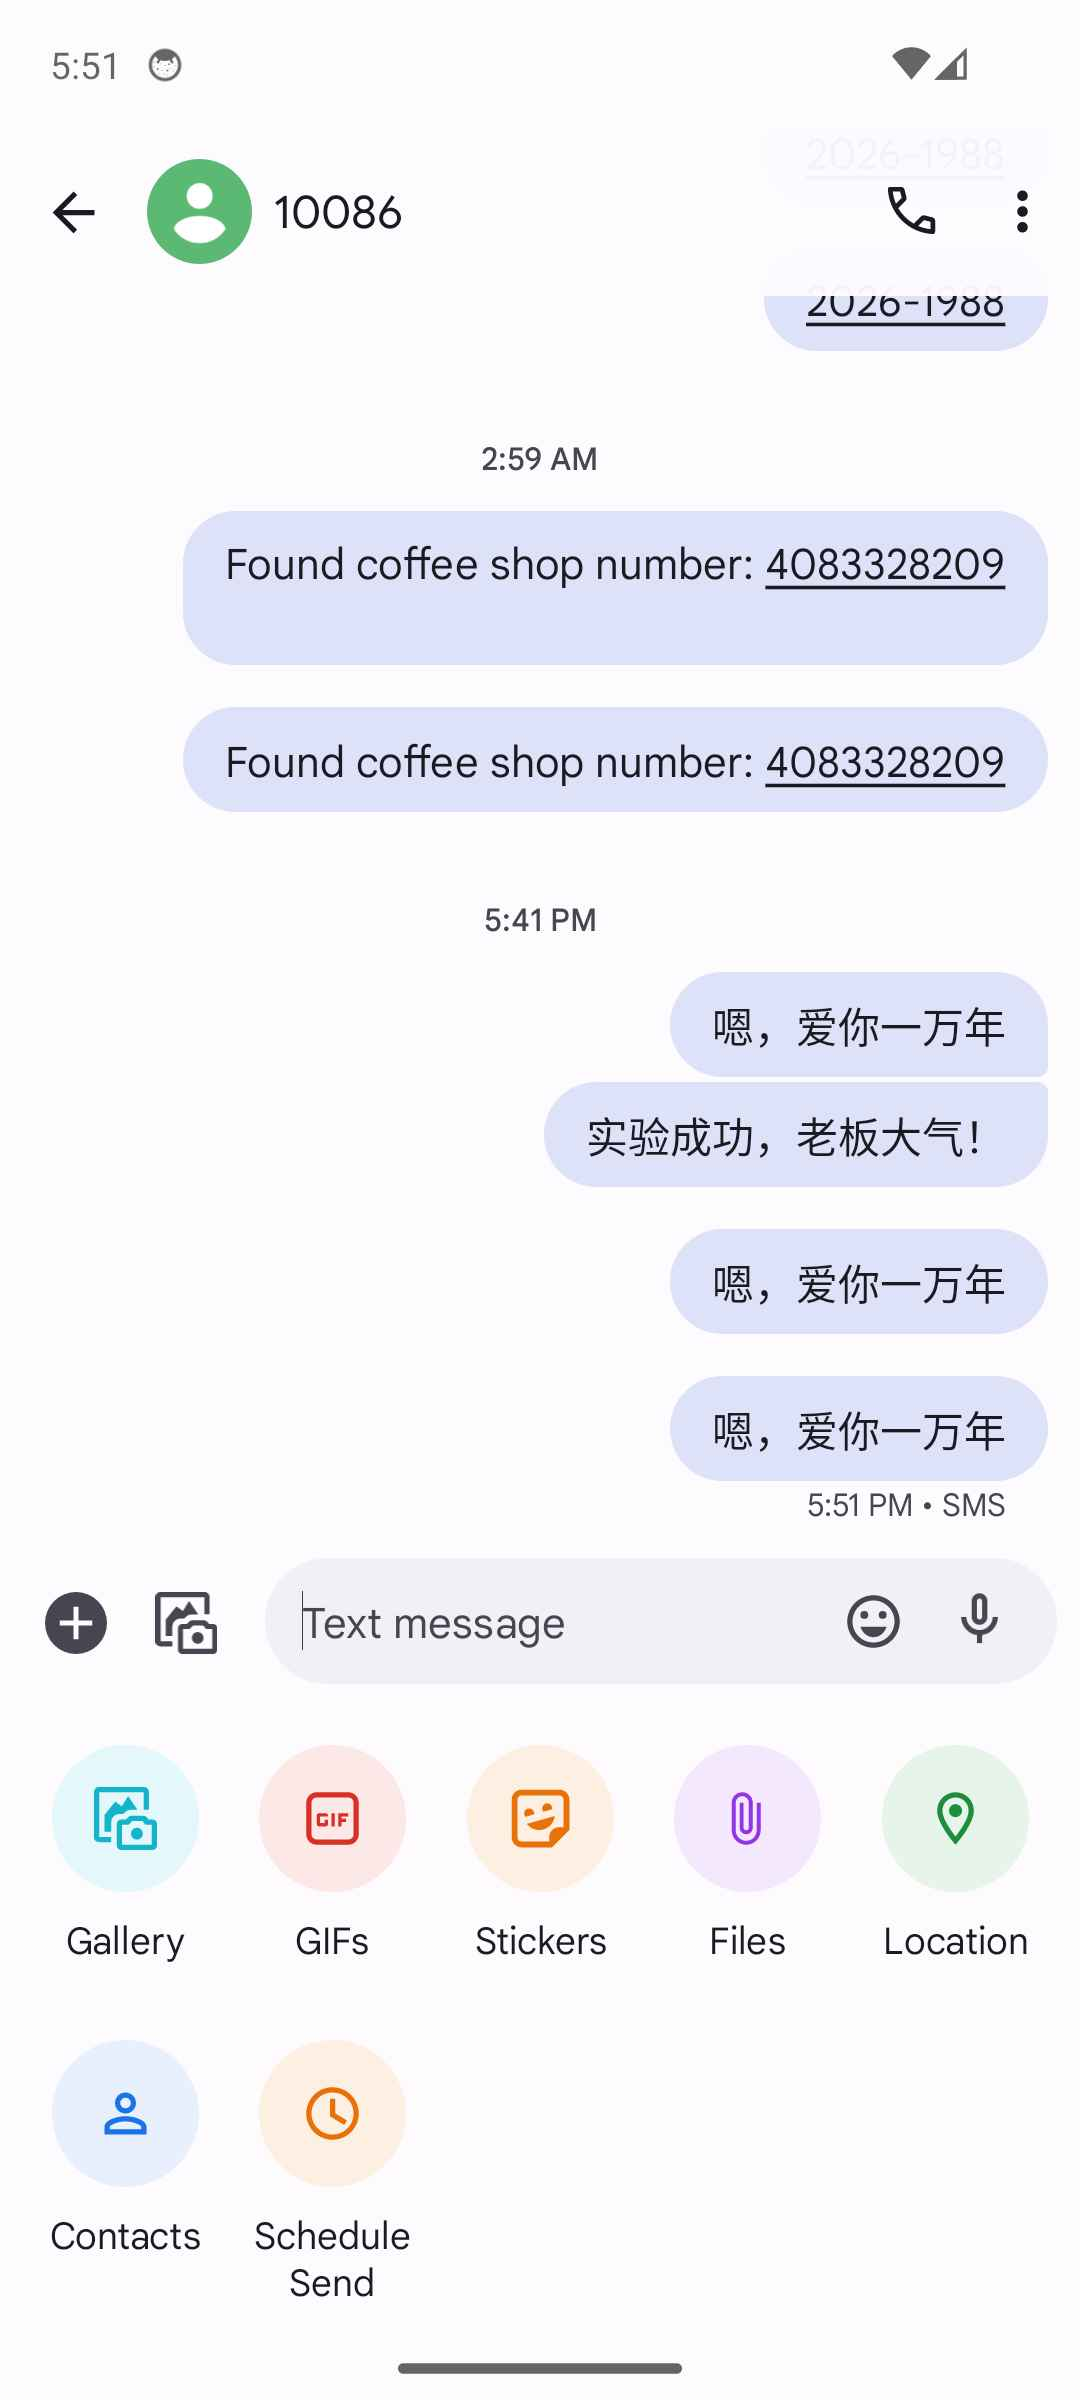

In [13]:
# === 请在此处修改参数 ===
target_id = 30      # 参考上面列表里的 [ID]
input_text = "嗯，爱你一万年"
action = "send"     # 可选: send, search, done, go, next
# =======================

if target_id < len(inv):
    target = inv[target_id]
    print(f"🚀 正在执行：点击 {target['label']} 并输入 '{input_text}' (Action: {action})")
    c.tap_and_type(target['pos'][0], target['pos'][1], input_text, editor_action=action)
    
    # 执行完自动刷新一次看结果
    time.sleep(1)
    c.take_screenshot("profiling/last_action_result.png")
    display(Image(filename="profiling/last_action_result.png"))
else:
    print("❌ 错误的 ID")